# Lab 09: Sparse Autoencoders & Mechanistic Interpretability — **A100 Edition**
**Duration**: 120 min | **Prerequisites**: Lab 07 (Transformers), Lab 08 (Hugging Face)  
**GPU**: Colab Pro A100 80 GB — Runtime → Change runtime type → A100 GPU with high ram on

## 🎯 Learning Objectives
- Explain why neural networks exhibit **polysemanticity**
- Understand what a Sparse Autoencoder does, conceptually
- Extract and identify features from **Gemma 2 9B** on philosophical text
- Test whether features are genuine concept encodings or **dataset artifacts**
- **Prove causation** — not just correlation — using activation steering and suppression ablation
- Understand what SAE-based interpretability can and cannot establish

## 📚 Pre-Lab Reading (30 min)
| Resource | What to focus on |
|----------|------------------|
| [Towards Monosemanticity — Cunningham et al., 2023](https://transformer-circuits.pub/2023/monosemantic-features/index.html) | Intro + all figures (~15 min) — skip the math |
| [3Blue1Brown — What is a Neural Network?](https://www.youtube.com/watch?v=aircAruvnKk) | Full video (~19 min) |

## 🔑 Before You Start: Hugging Face Access for Gemma
Gemma 2 is a **gated model**. Before running Part 3, you need to:
1. Create a [Hugging Face account](https://huggingface.co/join)
2. Accept the license at [huggingface.co/google/gemma-2-9b](https://huggingface.co/google/gemma-2-9b) (instant approval)
3. Create an access token at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) (read-only is fine)

The model-loading cell will prompt you to paste the token.

## 🚀 Why This Version Exists
This is the **A100 / Colab Pro** version of Lab 09. The free-T4 notebook ([Lab09_SAE.ipynb](Lab09_SAE.ipynb)) uses GPT-2 Small + Joseph Bloom's SAEs — a tight fit on free Colab but produces noisier features and only subtle steering effects.

This notebook uses **Gemma 2 9B** (9.2B parameters) with **DeepMind's Gemma Scope SAEs** — the current gold-standard public SAE release. Expect:
- Dramatically cleaner, more monosemantic features
- Steering effects you can actually *see* in the output
- More interpretable cross-register results
- ~5–7 min initial model download (~18 GB) + ~3 min processing

The pedagogical workflow is identical to the free version; only the model and SAE differ.

In [1]:
!pip install -q sae-lens transformer-lens accelerate
print('✅ Installation complete!')

✅ Installation complete!


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os
from transformer_lens import HookedTransformer
from sae_lens import SAE

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cpu':
    print('⚠️  No GPU detected. Go to Runtime → Change runtime type → A100 GPU.')
elif torch.cuda.get_device_name(0).startswith(('Tesla T4', 'T4')):
    print('⚠️  Detected T4 — this notebook requires A100. Either:')
    print('    - switch to the free-T4 notebook (Lab09_SAE.ipynb), OR')
    print('    - Runtime → Change runtime type → A100 GPU.')
else:
    print(f'✅ GPU ready: {torch.cuda.get_device_name(0)}')

Using device: cuda
✅ GPU ready: NVIDIA A100-SXM4-80GB


## Part 1: Polysemanticity — Why Neurons Are Hard to Interpret (15 min)

### 📚 The Problem
A **polysemantic** neuron fires for many unrelated concepts. For example, neuron 2049 in GPT-2 activates for the word "banana", the color yellow, and curved shapes — and dozens of other unrelated things.

This makes it nearly impossible to understand what any single neuron "means."

### 📚 Why Does This Happen? — The Superposition Hypothesis
Networks have *fewer neurons* than there are real-world features to represent. To pack more information in, they store features in **superposition**: overlapping directions in activation space.

> "A model can represent more features than it has neurons, as long as the features are sparse." — Elhage et al., 2022

The toy model below demonstrates this. Five real-world features are packed into a 2D space.

Training toy model...
✅ Done. Reconstruction loss: 0.0044


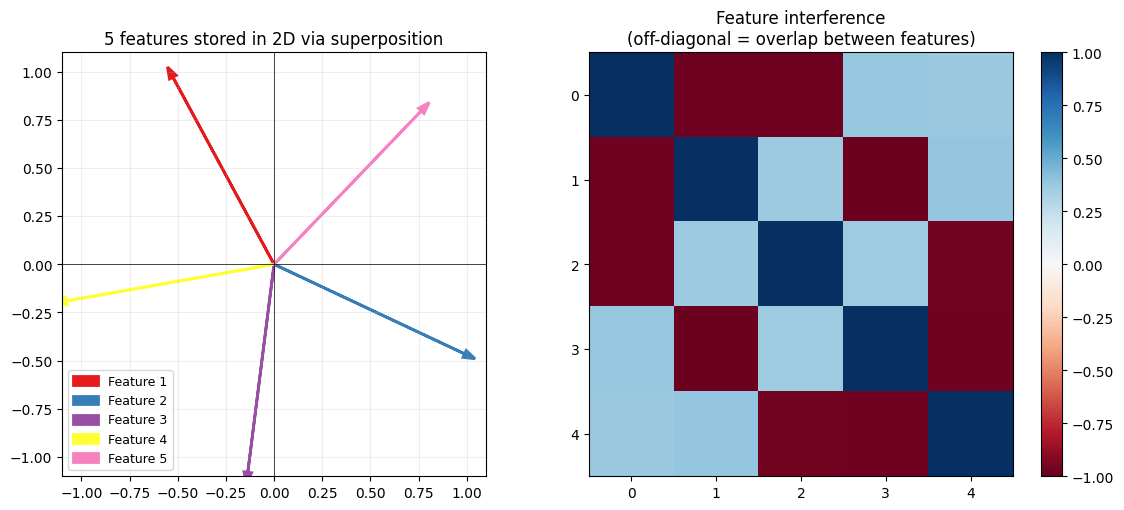

In [3]:
# 🔍 DEMONSTRATION: Toy Model of Superposition

def create_sparse_data(n_features=5, n_hidden=2, batch=2000, sparsity=0.1):
    x    = torch.rand(batch, n_features)
    mask = torch.bernoulli(torch.full_like(x, sparsity))
    return x * mask

class ToyModel(nn.Module):
    def __init__(self, n_features=5, n_hidden=2):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_features) * 0.3)
        self.b = nn.Parameter(torch.zeros(n_features))
    def forward(self, x):
        h = x @ self.W.T
        return torch.relu(h @ self.W + self.b)

toy_model = ToyModel()
opt       = torch.optim.Adam(toy_model.parameters(), lr=0.01)
print('Training toy model...')
for step in range(3000):
    x    = create_sparse_data()
    loss = ((x - toy_model(x)) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print(f'✅ Done. Reconstruction loss: {loss.item():.4f}')

W      = toy_model.W.detach().numpy()
colors = plt.cm.Set1(np.linspace(0, 0.8, 5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(5):
    axes[0].arrow(0, 0, W[0, i], W[1, i], head_width=0.04,
                  color=colors[i], label=f'Feature {i+1}', linewidth=2)
axes[0].set_xlim(-1.1, 1.1); axes[0].set_ylim(-1.1, 1.1)
axes[0].set_aspect('equal')
axes[0].set_title('5 features stored in 2D via superposition')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

feat_vecs    = W.T
interference = feat_vecs @ feat_vecs.T
im = axes[1].imshow(interference, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Feature interference\n(off-diagonal = overlap between features)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

### 📖 Reading the Diagram

**Why can't we read off "Feature 3" from the neurons directly?**  
The 2D space (the neurons) combines all five features simultaneously. Each neuron's value is a weighted mixture of multiple feature contributions. There is no one-to-one mapping between a neuron and a concept — the mapping is many-to-many.

**A philosophical analogy**: this is the same structure as lexical ambiguity. The English word "right" doesn't isolate a single concept — it blends legal entitlement, moral correctness, and spatial direction. Context resolves the ambiguity. Neurons are ambiguous in the same way; context in the surrounding layers has to resolve what each neuron "means" at any given moment. The SAE's job is to find the unambiguous underlying concepts.

**What the SAE does**: It recovers the 5 original arrows from the tangled 2D space. In Gemma 2 9B, it recovers **16,384 concept-directions** from a 3,584-dimensional residual stream — a ~4.6× expansion that gives each feature room to specialize. (Gemma Scope also ships 131k- and 1M-feature SAEs for 9B if you want to push further.) The next section explains how.

## Part 2: How Sparse Autoencoders Work — Conceptual Tour (10 min)

### Architecture

```
Input: activation vector  [3,584 numbers from Gemma 2 9B layer 31]
            │
            ▼  Encoder: linear projection + JumpReLU (Gemma Scope's activation)
            │
    Feature activations  [16,384 numbers — most are ZERO]
            │
            ▼  Decoder: linear projection
            │
    Reconstructed input  [3,584 numbers, close to original]
```

### Three Key Ideas

**1. Expansion**: 3,584 dimensions → 16,384 features (~4.6×). This gives enough room for every concept to occupy its own direction rather than sharing one. (Gemma Scope ships 131k and 1M widths too — much more granular, but 16k is plenty for an educational pass.)

**2. Sparsity penalty**: A penalty term during training pushes most of the 16,384 values to zero. For any given token, only ~80–150 features activate.

**3. Why sparsity leads to monosemanticity**: If you are allowed to use only ~100 pencils out of 16,384, you choose precisely. Each pencil ends up encoding exactly the thing it is best at. Features that try to encode two unrelated concepts lose to specialized features in a competitive training regime.

*(In theory. Part 5 tests whether this holds in practice — and at 9B scale, it largely does.)*

In [4]:
# 📖 REFERENCE CODE — the SAE architecture; you do not need to modify this.

class SparseAutoencoder(nn.Module):
    '''
    Sparse Autoencoder: x → [linear + ReLU] → features → [linear] → x_recon
    Loss = reconstruction_error + lambda * L1_sparsity_penalty
    '''
    def __init__(self, d_model, d_sae, l1_coeff=0.001):
        super().__init__()
        self.W_enc = nn.Parameter(torch.randn(d_model, d_sae) / (d_model ** 0.5))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.randn(d_sae, d_model) / (d_sae ** 0.5))
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.l1_coeff = l1_coeff

    def encode(self, x):
        return torch.relu(x @ self.W_enc + self.b_enc)

    def decode(self, features):
        return features @ self.W_dec + self.b_dec

    def forward(self, x):
        features      = self.encode(x)
        x_recon       = self.decode(features)
        recon_loss    = ((x - x_recon) ** 2).mean()
        sparsity_loss = self.l1_coeff * features.abs().sum(-1).mean()
        return x_recon, features, recon_loss + sparsity_loss

demo_sae    = SparseAutoencoder(d_model=64, d_sae=256)
dummy       = torch.randn(4, 10, 64)
_, feats, _ = demo_sae(dummy)
print(f'Input:    {list(dummy.shape)}')
print(f'Features: {list(feats.shape)}  ← 256 features from 64 dims (4× expansion)')
print(f'Sparsity: {(feats == 0).float().mean().item():.0%} of features are zero')

Input:    [4, 10, 64]
Features: [4, 10, 256]  ← 256 features from 64 dims (4× expansion)
Sparsity: 50% of features are zero


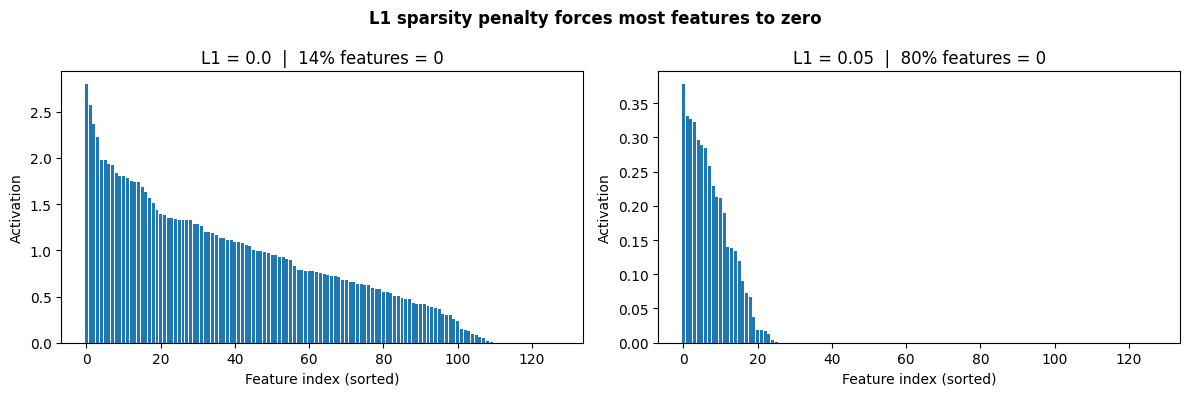

In [5]:
# 🔍 DEMONSTRATION: Effect of the L1 sparsity penalty
# Left: no penalty → features spread out. Right: L1=0.05 → most features collapse to zero.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dummy_1d   = torch.randn(500, 64)

for ax, l1 in zip(axes, [0.0, 0.05]):
    sae_test = SparseAutoencoder(d_model=64, d_sae=128, l1_coeff=l1)
    opt_t    = torch.optim.Adam(sae_test.parameters(), lr=0.005)
    for _ in range(800):
        _, feats, loss_t = sae_test(dummy_1d)
        opt_t.zero_grad(); loss_t.backward(); opt_t.step()
    with torch.no_grad():
        _, feats, _ = sae_test(dummy_1d[:1])
    feat_vals = feats[0].detach().numpy()
    ax.bar(range(len(feat_vals)), sorted(feat_vals, reverse=True))
    ax.set_title(f'L1 = {l1}  |  {(feat_vals == 0).mean():.0%} features = 0')
    ax.set_xlabel('Feature index (sorted)'); ax.set_ylabel('Activation'); ax.set_ylim(0, None)

plt.suptitle('L1 sparsity penalty forces most features to zero', fontweight='bold')
plt.tight_layout(); plt.show()

## Part 3: Using a Pretrained SAE on Gemma 2 9B (20 min)

### 📚 Gemma Scope

In July 2024, Google DeepMind released [**Gemma Scope**](https://deepmind.google/discover/blog/gemma-scope-helping-the-safety-community-shed-light-on-the-inner-workings-of-language-models/) — a comprehensive suite of SAEs trained on every layer of every size of Gemma 2 (2B, 9B, 27B). It is currently the gold-standard public SAE release. We use the **9B model**, **layer 31** (of 42), and the **16k-wide canonical SAE** — 16,384 features over a 3,584-dim residual stream.

Layer 31 sits roughly 75% through the network, the same depth ratio we'd use for the 2B model. It carries rich semantic content (concepts, entities, abstractions, even some compositional structure) while still being a few layers shy of the next-token-prediction logic that dominates the final layers.

---

### 🎯 What to Expect at 9B Scale

Compared to the free-T4 (GPT-2 Small) version, you should see:

- **Clean, often single-concept features.** Many will have crisp Neuronpedia labels — e.g. *"discussions of fairness in legal contexts"* rather than *"phrases related to actions"*.
- **Visible steering effects.** Adding the feature direction at strength 100–200 should produce noticeably different completions, not just subtle drift.
- **Real cross-register robustness.** A genuine concept feature at 9B usually activates across web, academic, legal, and literary registers without much variance — much closer to true monosemanticity.
- **A handful of multilingual features.** Gemma 2 was trained on substantial non-English data, so cross-lingual probing actually works at this scale.

If a feature *doesn't* meet these expectations, that's diagnostic information — likely the feature is genuinely polysemantic or context-dependent, not just a scale artifact.

---

### 🔍 How to Look Up a Feature on Neuronpedia

The code in this section prints feature indices like `Feature  3842  avg=0.214`. To look up what feature 3842 encodes, run this in a code cell:

```python
print(neuronpedia_url(3842))
# → https://neuronpedia.org/gemma-2-9b/31-gemmascope-res-16k/3842
```

Copy that link into your browser. That is it — replace `3842` with whichever feature index you want to inspect.

**What you will see on the page — read in this order:**

**① Explanations** *(top of the page)*  
2–3 AI systems (GPT-4o-mini, Gemini, Claude) have each written a short label for what the feature encodes. **Start here.** If all three agree on a theme, the label is likely reliable. At 9B scale, agreement is far more common than at GPT-2 scale.

**② Positive logits** *(table on the right)*  
The tokens the model becomes more likely to produce when this feature fires strongly. Scan the top 5–10. If they cluster around a theme (e.g. all are moral/legal vocabulary), that theme is likely what the feature encodes.

**③ Negative logits** *(below the positive logits)*  
Tokens the feature suppresses. The contrast with the positive logits often sharpens the picture — e.g. "ethical terms up, casual slang down" suggests the feature encodes *register* rather than a concept.

**④ Activation examples** *(lower on the page)*  
Individual tokens are highlighted in orange. Look only at the highlighted words across examples, not the full sentences. Gemma Scope 9B features generally have rich, easy-to-read activation examples.

> ⚠️ **Remember**: all labels, logits, and examples are derived from a web/code/multilingual training mix. The interpretation reflects how a concept appears *in that corpus*. Part 5 tests whether the label holds across other text types. Part 6 proves it causally.

---

In [6]:
# Authenticate with Hugging Face. Gemma 2 is a gated model — you must:
#   1. Accept the license at https://huggingface.co/google/gemma-2-9b
#   2. Create a read-only token at https://huggingface.co/settings/tokens
#   3. Paste it into the widget below.
from huggingface_hub import notebook_login
notebook_login()

In [7]:
# Loading Gemma 2 9B + its layer-31 Gemma Scope SAE.
#
# A100 40 GB has plenty of VRAM, so we don't need the elaborate
# memory tricks from the free-T4 version. But we still:
#   - use bf16 to fit comfortably (~18 GB model + ~150 MB SAE + activations)
#   - use `from_pretrained_no_processing` because Gemma Scope SAEs were
#     trained on the *raw* residual stream — TransformerLens's default
#     weight transformations would change what the SAE sees.
#
# First-run download: ~18 GB. Allow 5–7 min on a good Colab connection.

import gc
from transformers import AutoModelForCausalLM, AutoTokenizer

print('Downloading Gemma 2 9B (bf16, ~18 GB)...')
tokenizer = AutoTokenizer.from_pretrained('google/gemma-2-9b')
hf_model  = AutoModelForCausalLM.from_pretrained(
    'google/gemma-2-9b',
    torch_dtype=torch.bfloat16,
    device_map='auto',
    low_cpu_mem_usage=True,
)

print('Wrapping with TransformerLens (no processing, raw residual stream)...')
model = HookedTransformer.from_pretrained_no_processing(
    'gemma-2-9b',
    hf_model=hf_model,
    tokenizer=tokenizer,
    dtype=torch.bfloat16,
    device=device,
)
model.eval()

del hf_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Loading Gemma Scope SAE — layer 31, width 16k, canonical...')
sae = SAE.from_pretrained(
    release='gemma-scope-9b-pt-res-canonical',
    sae_id='layer_31/width_16k/canonical',
    device=device,
)
sae.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'\n✅ Gemma 2 9B:   {n_params:,} parameters')
print(f'✅ SAE loaded:   {sae.cfg.d_sae:,} features  (from {sae.cfg.d_in}-dim residual stream)')
print(f'✅ Expansion:    {sae.cfg.d_sae / sae.cfg.d_in:.1f}×')
print(f'✅ Hook point:   blocks.31.hook_resid_post  (where Gemma Scope trained this SAE)')

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Wrapping with TransformerLens (no processing, raw residual stream)...
Loaded pretrained model gemma-2-9b into HookedTransformer
Loading Gemma Scope SAE — layer 31, width 16k, canonical...

✅ Gemma 2 9B:   10,160,713,216 parameters
✅ SAE loaded:   16,384 features  (from 3584-dim residual stream)
✅ Expansion:    4.6×
✅ Hook point:   blocks.31.hook_resid_post  (where Gemma Scope trained this SAE)


In [8]:
# Helper functions used throughout the lab

def get_feature_activations(text, model, sae, layer=31):
    tokens     = model.to_tokens(text, prepend_bos=True)
    token_strs = [model.tokenizer.decode([t]) for t in tokens[0]]
    hook_name  = f'blocks.{layer}.hook_resid_post'
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=hook_name)
    with torch.no_grad():
        feature_acts = sae.encode(cache[hook_name])
    return token_strs, feature_acts[0]   # [seq, d_sae]

def find_top_features(text, model, sae, k=10, layer=31):
    _, feature_acts     = get_feature_activations(text, model, sae, layer)
    top_values, top_idx = torch.topk(feature_acts.mean(dim=0).float(), k)
    return list(zip(top_idx.tolist(), top_values.tolist()))

def find_concept_features(concept_texts, model, sae, k=5, layer=31):
    '''Average top features across multiple sentences expressing the same concept.'''
    accumulated = torch.zeros(sae.cfg.d_sae)
    for text in concept_texts:
        _, feature_acts = get_feature_activations(text, model, sae, layer)
        accumulated    += feature_acts.mean(dim=0).cpu().float()
    top_values, top_indices = torch.topk(accumulated / len(concept_texts), k)
    return list(zip(top_indices.tolist(), top_values.tolist()))

def neuronpedia_url(feature_idx, layer=31):
    '''Generate a Neuronpedia link for any feature (see instructions in Part 3 above).'''
    return f'https://neuronpedia.org/gemma-2-9b/{layer}-gemmascope-res-16k/{feature_idx}'

print('✅ Helper functions ready.')

✅ Helper functions ready.


In [9]:
# 🔍 DEMONSTRATION: Top SAE features for the Kant quote

kant_quote = 'Act only according to that maxim by which you can at the same time will it to become a universal law.'
top_feats  = find_top_features(kant_quote, model, sae, k=10)

print('Top 10 SAE features for the Kant quote:')
for rank, (feat_idx, activation) in enumerate(top_feats, 1):
    print(f'  #{rank:2d}  Feature {feat_idx:5d}  avg_act={activation:.3f}')
print()
print(f'Example Neuronpedia link (top feature): {neuronpedia_url(top_feats[0][0])}')
print('Use the instructions in Part 3 to look up any feature index above.')

Top 10 SAE features for the Kant quote:
  # 1  Feature  1126  avg_act=109.691
  # 2  Feature   319  avg_act=107.398
  # 3  Feature  9005  avg_act=89.825
  # 4  Feature  7007  avg_act=73.320
  # 5  Feature  6782  avg_act=52.691
  # 6  Feature  1877  avg_act=47.101
  # 7  Feature   263  avg_act=47.018
  # 8  Feature  1436  avg_act=28.926
  # 9  Feature  5576  avg_act=22.588
  #10  Feature 11819  avg_act=21.442

Example Neuronpedia link (top feature): https://neuronpedia.org/gemma-2-9b/31-gemmascope-res-16k/1126
Use the instructions in Part 3 to look up any feature index above.


In [10]:
# Compare top features across three philosophical traditions
philosophical_quotes = [
    ('Kant',      'Act only according to that maxim by which you can will it to become universal law.'),
    ('Aristotle', 'The good life is one inspired by love and guided by knowledge.'),
    ('Rawls',     'Justice is the first virtue of social institutions, as truth is of systems of thought.'),
]

print('Top-5 SAE features for each philosophical quote:')
print('=' * 55)
for author, quote in philosophical_quotes:
    print(f'\n{author}: "{quote[:55]}..."')
    for rank, (feat_idx, act) in enumerate(find_top_features(quote, model, sae, k=5), 1):
        print(f'  #{rank}  Feature {feat_idx:5d}  avg_act={act:.3f}')

Top-5 SAE features for each philosophical quote:

Kant: "Act only according to that maxim by which you can will ..."
  #1  Feature  1126  avg_act=121.599
  #2  Feature   319  avg_act=103.303
  #3  Feature  9005  avg_act=96.239
  #4  Feature  7007  avg_act=77.094
  #5  Feature  6782  avg_act=67.328

Aristotle: "The good life is one inspired by love and guided by kno..."
  #1  Feature  1126  avg_act=121.882
  #2  Feature  9005  avg_act=111.535
  #3  Feature  6782  avg_act=100.335
  #4  Feature   263  avg_act=78.219
  #5  Feature  7007  avg_act=57.735

Rawls: "Justice is the first virtue of social institutions, as ..."
  #1  Feature  9005  avg_act=106.307
  #2  Feature  1126  avg_act=103.376
  #3  Feature   319  avg_act=79.486
  #4  Feature  6782  avg_act=75.729
  #5  Feature  7007  avg_act=60.789


## Part 4: Feature Exploration — Finding Philosophical Concepts (20 min)

### 📚 What do SAE features represent?

Anthropic's *Scaling Monosemanticity* paper found features for specific people, places, abstract concepts (ethics, justice, deception), emotional valence, and grammatical structure across layers of Claude 3 Sonnet.

Gemma 2 9B's Gemma Scope SAE (16,384 features at layer 31) contains a similarly rich vocabulary — at substantially better quality than the GPT-2 SAEs in the free version. Below, we systematically hunt for features that activate for philosophical concepts. Finding one is the **first step** — but it is only correlation. Parts 5 and 6 establish whether the finding is meaningful.

In [11]:
# 🔍 DEMONSTRATION: Finding concept features via sentence averaging
# Average feature activations across multiple sentences expressing the same concept.
# Features that activate consistently across all sentences are likely tied to the concept itself.

justice_texts = [
    'Justice requires that we treat all people fairly and equally regardless of background.',
    'The justice system must be blind to race, gender, and wealth when applying the law.',
    'Distributive justice concerns the fair allocation of resources across society.',
]
knowledge_texts = [
    'Knowledge is justified true belief, according to the traditional epistemological account.',
    'We can only claim to know something if we have good evidence and a reliable process.',
    'The limits of knowledge define the boundaries of what we can say with certainty.',
]

print('Features consistently activated by JUSTICE:')
for feat_idx, act in find_concept_features(justice_texts, model, sae):
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('Features consistently activated by KNOWLEDGE:')
for feat_idx, act in find_concept_features(knowledge_texts, model, sae):
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('These are correlation results — the features activate when the concept is present.')
print('Parts 5 and 6 will determine whether this is real or an artifact.')

Features consistently activated by JUSTICE:
  Feature  1126  avg=134.964
  Feature  9005  avg=124.010
  Feature  6782  avg=121.340
  Feature   263  avg=78.791
  Feature  7007  avg=67.072

Features consistently activated by KNOWLEDGE:
  Feature  1126  avg=138.032
  Feature  9005  avg=126.186
  Feature  6782  avg=121.261
  Feature   263  avg=75.480
  Feature  7007  avg=72.718

These are correlation results — the features activate when the concept is present.
Parts 5 and 6 will determine whether this is real or an artifact.


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR CONCEPT  — change the two items marked below, then run this cell.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

your_concept = 'virtue'   # ← ✏️  change to your concept
# Other ideas: 'freedom', 'consciousness', 'rights', 'truth', 'identity', 'duty', 'harm', 'autonomy'

your_concept_texts = [    # ← ✏️  replace these three sentences with your own
    'Virtue ethics holds that moral character is more fundamental than rules or consequences.',
    'Aristotle argued that virtues are stable dispositions to feel and act in appropriate ways.',
    'The cultivation of virtue requires habituation — we become courageous by performing courageous acts.',
]

# ──────────────────────────────────── nothing to change below this line ──────

your_features = find_concept_features(your_concept_texts, model, sae, k=5)
print(f'Top features for {your_concept.upper()}:')
for feat_idx, act in your_features:
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('Note these feature indices — you will test them in Part 5 and prove them causally in Part 6.')
print(f'Optional look-up: {neuronpedia_url(your_features[0][0])}')

Top features for VIRTUE:
  Feature  1126  avg=134.554
  Feature  9005  avg=111.906
  Feature  6782  avg=100.333
  Feature  7007  avg=73.504
  Feature   263  avg=72.370

Note these feature indices — you will test them in Part 5 and prove them causally in Part 6.
Optional look-up: https://neuronpedia.org/gemma-2-9b/31-gemmascope-res-16k/1126


Top feature on Rawls quote: #9005


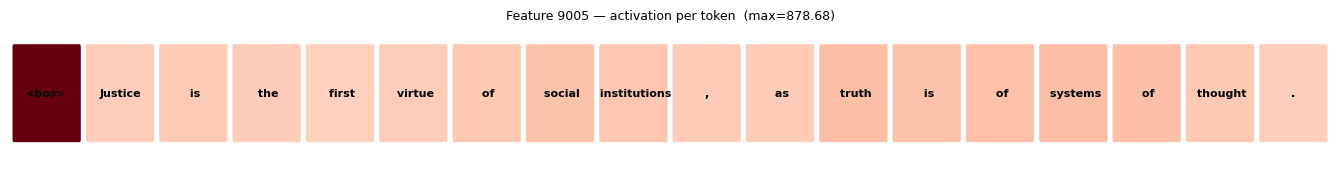

Darker red = stronger activation.
If the feature encodes a concept, the semantically loaded tokens should light up.


In [13]:
# 🔍 DEMONSTRATION: Token-level heatmap — which words drive the feature?

def plot_token_heatmap(text, feature_idx, model, sae, layer=31):
    token_strs, feature_acts = get_feature_activations(text, model, sae, layer)
    activations = feature_acts[:, feature_idx].cpu().float().numpy()
    max_act     = activations.max()
    if max_act < 1e-8:
        print(f'Feature {feature_idx} does not activate on this text.'); return
    norm_acts = activations / max_act
    fig, ax = plt.subplots(figsize=(max(10, len(token_strs) * 0.75), 1.8))
    ax.set_xlim(0, len(token_strs)); ax.set_ylim(0, 1); ax.axis('off')
    for i, (tok, norm) in enumerate(zip(token_strs, norm_acts)):
        color = plt.cm.Reds(0.15 + 0.85 * float(norm))
        ax.add_patch(mpatches.FancyBboxPatch(
            (i + 0.05, 0.15), 0.9, 0.70, boxstyle='round,pad=0.03',
            facecolor=color, edgecolor='white', lw=1.5))
        ax.text(i + 0.5, 0.5, tok, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'Feature {feature_idx} — activation per token  (max={max_act:.2f})', fontsize=9, pad=6)
    plt.tight_layout(); plt.show()

rawls_quote = 'Justice is the first virtue of social institutions, as truth is of systems of thought.'
top_rawls   = find_top_features(rawls_quote, model, sae, k=3)
print(f'Top feature on Rawls quote: #{top_rawls[0][0]}')
plot_token_heatmap(rawls_quote, top_rawls[0][0], model, sae)
print('Darker red = stronger activation.')
print('If the feature encodes a concept, the semantically loaded tokens should light up.')

## Part 5: Are These Findings Real? Testing for Dataset Artifacts (25 min)

### 📚 The Correlation Problem

Finding that Feature X activates on "justice" text is a **correlation**: the feature and the concept co-occur. But correlations can be spurious.

The specific risk here is called a **dataset artifact**: a feature may appear to encode "justice" only because the test sentences all came from the same corpus — web text (Reddit, Wikipedia, news articles). In that corpus, justice appears overwhelmingly in political commentary, activism, and legal news. The feature might actually encode *that rhetorical register*, not justice as a philosophical concept.

This mirrors a classical problem in **conceptual analysis**: are we capturing the concept itself, or only the culturally specific contexts in which it appears in our evidence base?

### 🧪 The Cross-Register Test

A genuine concept feature should activate **regardless of the stylistic register** in which the concept appears. We test four:

| Register | Hypothesis |
|---------|-----------|
| **Web / informal** | High activation — this is Neuronpedia's home corpus |
| **Academic philosophy** | If truly monosemantic, should still activate |
| **Legal / institutional** | Different genre, same concept |
| **Literary fiction** | Thematic rather than argumentative treatment |

High activation in **only one register** → likely a dataset artifact.  
Consistent activation **across all four** → stronger evidence for genuine concept encoding.

**Important**: Even consistent cross-register activation is still only correlation. It rules out a simple style artifact, but cannot establish that the feature *causes* concept-related behavior. That requires Part 6.

In [14]:
# Four registers of justice discourse

domain_texts = {
    'Web / informal': [
        'Justice needs to be served — these politicians need to be held accountable for what they did.',
        "There's no justice in this world when rich people can just buy their way out of anything.",
        'We need to fight for justice for all marginalized communities in this country, period.',
    ],
    'Academic philosophy': [
        'Rawlsian justice requires that inequalities benefit the least advantaged members of society.',
        'The concept of distributive justice addresses moral principles governing the fair allocation of goods.',
        'Aristotelian justice as proportional equality differs fundamentally from egalitarian conceptions.',
    ],
    'Legal / institutional': [
        'Procedural justice demands notice and opportunity to be heard before deprivation of rights.',
        'Criminal justice reform advocates argue mandatory minimums undermine proportionate sentencing.',
        'Restorative justice seeks to address harm through cooperative processes rather than punitive ones.',
    ],
    'Literary fiction': [
        'She had always believed in justice, but standing before the judge she wondered if it was just a word.',
        'The old man spoke of justice as if it were a tangible thing you could hold and weigh.',
        'In that village, justice meant whatever the powerful decided it meant on any given day.',
    ],
}
print('Domain texts ready.')

Domain texts ready.


In [15]:
# Analysis tools — pre-written

def compare_feature_across_domains(feature_idx, domain_texts, model, sae, layer=31):
    results = {}
    for domain_name, texts in domain_texts.items():
        per_text = []
        for text in texts:
            _, feature_acts = get_feature_activations(text, model, sae, layer)
            per_text.append(feature_acts[:, feature_idx].mean().item())
        results[domain_name] = {'mean': float(np.mean(per_text)), 'activations': per_text}
    return results

def plot_domain_comparison(feature_idx, results, concept_label=''):
    domains = list(results.keys())
    means   = [results[d]['mean'] for d in domains]
    colors  = ['#e07b54', '#5b8dd9', '#58b368', '#9b59b6']
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(domains, means, color=colors[:len(domains)], width=0.55, edgecolor='white', lw=1.5)
    ax.set_title(f'Feature {feature_idx}' + (f' ("{concept_label}")' if concept_label else ''), fontsize=10)
    ax.set_ylabel('Average activation'); ax.set_ylim(0, max(means) * 1.4 + 0.005)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=12, ha='right'); plt.tight_layout(); plt.show()
    ratio = max(means) / (min(means) + 1e-8)
    print(f'Activation range: {min(means):.3f} – {max(means):.3f}  (ratio: {ratio:.1f}×)')
    if ratio > 3:
        print('⚠️  HIGH domain sensitivity. Risk of dataset artifact.')
        print('   Activates much more in one register than others.')
        print('   Proceed to Part 6 — causal testing is essential here.')
    else:
        print('✅ Relatively domain-invariant.')
        print('   Consistent activation across registers is a good sign.')
        print('   Still need causal proof in Part 6.')

print('Analysis tools ready.')

Analysis tools ready.


Testing Feature #6782


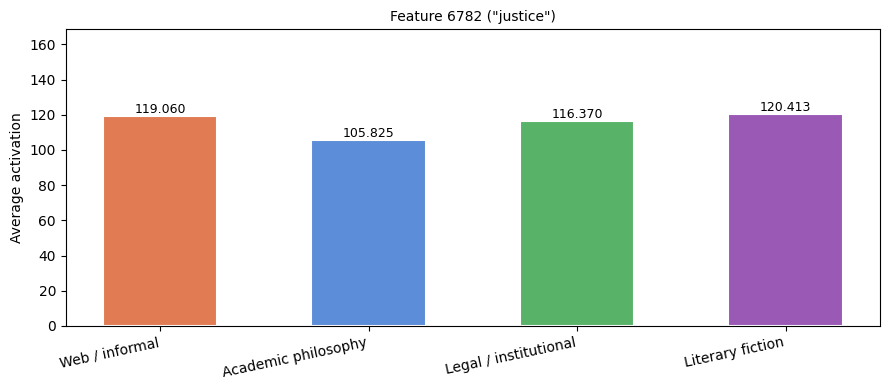

Activation range: 105.825 – 120.413  (ratio: 1.1×)
✅ Relatively domain-invariant.
   Consistent activation across registers is a good sign.
   Still need causal proof in Part 6.


In [16]:
# 🔍 DEMONSTRATION: Cross-register test for the justice feature

justice_probe = 'Justice requires that we treat all people fairly and equally.'
justice_feat  = find_top_features(justice_probe, model, sae, k=1)[0][0]

print(f'Testing Feature #{justice_feat}')
results_justice = compare_feature_across_domains(justice_feat, domain_texts, model, sae)
plot_domain_comparison(justice_feat, results_justice, concept_label='justice')

### 📖 Interpreting the Cross-Register Result

**If the bars are roughly equal** (ratio < 3×):  
The feature activates on justice text regardless of style. This *rules out* a simple style-based artifact. The feature is likely tracking the concept rather than the rhetorical register.

**If one bar is much higher** (ratio > 3×):  
The feature is sensitive to how justice is *expressed*, not only to the concept itself. The Neuronpedia label may be misleading — it reflects the most common register in the training corpus.

**Either way, correlation alone is not proof**.  
Suppose the feature passes the cross-register test. It is still possible that some *other* variable — academic register, ethical vocabulary, noun-phrase density — is the true cause of activation, and justice is just correlated with it in all four registers. To rule this out, we need to *intervene* on the feature and observe whether the behavior changes. That is Part 6.

In [17]:
# 🔍 OPTIONAL: Test against the PhilPapers dataset from Lab 02.01
# Real philosophy paper abstracts — the most demanding out-of-distribution test.
from google.colab import drive
drive.mount('/content/drive')


philpapers_path = "/content/drive/MyDrive/AIDE/philpapers_enhanced_clean.csv"
try:
    phil_df  = pd.read_csv(philpapers_path)
    text_col = next(
        (c for c in ['abstract', 'Abstract', 'text', 'body', 'title']
         if c in phil_df.columns and phil_df[c].notna().sum() > 10),
        phil_df.columns[0]
    )
    mask           = phil_df[text_col].str.contains('justice|fairness|equality', case=False, na=False)
    justice_papers = phil_df[mask][text_col].dropna().tolist()[:3]
    print(f'✅ {len(phil_df)} philosophy papers loaded; {len(justice_papers)} about justice/fairness.')

    if justice_papers:
        phil_results = compare_feature_across_domains(justice_feat,
                           {'PhilPapers abstracts': justice_papers}, model, sae)
        phil_mean    = phil_results['PhilPapers abstracts']['mean']
        web_mean     = results_justice.get('Web / informal', {}).get('mean', 0)
        ratio        = (web_mean + 1e-8) / (phil_mean + 1e-8)
        print(f'  Web/informal:  {web_mean:.3f}')
        print(f'  PhilPapers:    {phil_mean:.3f}  (ratio {ratio:.1f}×)')
        if ratio > 2:
            print('  ⚠️  Lower activation on real philosophy papers — web rhetoric may be driving the feature.')
        else:
            print('  ✅ Similar activation on real philosophy papers — promising.')
except FileNotFoundError:
    print('PhilPapers CSV not found. Upload from Lab02.01-Data Fundemantals/Data/ or mount Drive.')

Mounted at /content/drive
✅ 3776 philosophy papers loaded; 3 about justice/fairness.
  Web/informal:  119.060
  PhilPapers:    105.066  (ratio 1.1×)
  ✅ Similar activation on real philosophy papers — promising.


Testing Feature #1126 for VIRTUE across four registers


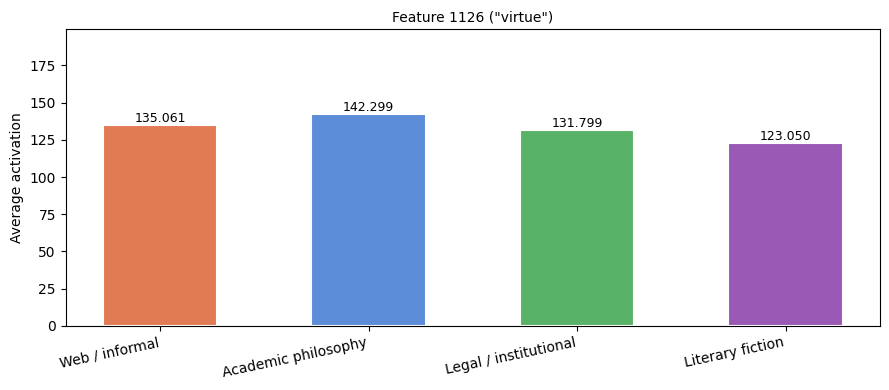

Activation range: 123.050 – 142.299  (ratio: 1.2×)
✅ Relatively domain-invariant.
   Consistent activation across registers is a good sign.
   Still need causal proof in Part 6.

Record the result: domain-invariant or domain-sensitive?
This informs how strongly to weight your causal test in Part 6.


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR DOMAIN TEXTS  — swap in four register-varied sentences for your concept.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

your_domain_texts = {    # ← ✏️  replace the sentences inside each register
    'Web / informal': [
        'Being a virtuous person means doing the right thing even when no one is watching.',
        'Virtue signaling is when people act good in public but are selfish in private.',
        'The most virtuous thing you can do is be honest, even when it hurts.',
    ],
    'Academic philosophy': [
        'For Aristotle, virtues are the golden mean between deficiency and excess of character traits.',
        'The unity of the virtues thesis holds that genuine virtue in one domain requires virtue in all.',
        'Virtue epistemology applies the character-based framework to intellectual excellences such as wisdom.',
    ],
    'Legal / institutional': [
        'Civic virtue — the disposition to prioritize the common good — is essential to democratic governance.',
        'Courts have recognized that evidence of a witness virtuous character is admissible in some proceedings.',
        'The virtuous public servant acts in the interest of constituents rather than personal gain.',
    ],
    'Literary fiction': [
        'She had always considered patience her greatest virtue, though today it was failing her.',
        'The old knight believed virtue to be worth more than all the gold in the kingdom.',
        'In the end, his only virtue was his stubbornness — and perhaps that was enough.',
    ],
}

# ──────────────────────────────────── nothing to change below this line ──────

your_feature_idx = your_features[0][0]   # automatically uses the top feature from Part 4

print(f'Testing Feature #{your_feature_idx} for {your_concept.upper()} across four registers')
your_results = compare_feature_across_domains(your_feature_idx, your_domain_texts, model, sae)
plot_domain_comparison(your_feature_idx, your_results, concept_label=your_concept)
print()
print('Record the result: domain-invariant or domain-sensitive?')
print('This informs how strongly to weight your causal test in Part 6.')

## Part 6: Proving Causation — Beyond Correlation (25 min)

### 📚 Why Correlation Is Not Enough

So far we have established:
- Feature X activates when justice text is present (Parts 3–4)
- Feature X activates across different text registers (Part 5)

This rules out simple style artifacts. But it is still consistent with the feature being a **passive detector** — a thermometer that reads the temperature without controlling it. The feature might correlate with justice because the same conditions that produce justice text also produce high feature activation, without the feature *doing* anything.

To establish genuine causal relevance, we need **interventions** — experiments where we change only the feature and observe the effect on behavior. This is precisely the logic of a controlled experiment.

We use two complementary interventions, following James Woodward's **manipulability theory of causation**: a variable is causally relevant to an outcome if manipulating it produces a corresponding change in the outcome.

---

### 🧪 The Three-Part Causal Test

| Test | What we do | What it shows |
|------|-----------|---------------|
| **1. Correlation** | Measure feature activation on concept text | Feature co-occurs with concept (Parts 3–5) |
| **2. Activation (steering)** | *Add* the feature direction to residual stream | Does artificially activating the feature produce concept-related output? |
| **3. Suppression (ablation)** | *Remove* the feature direction from residual stream | Does suppressing the feature reduce concept-related output? |

If tests 2 and 3 both succeed, we have **convergent causal evidence**: the feature promotes the concept when added and suppresses it when removed. This is the same evidential standard used in neuroscience to claim that a brain region "encodes" something.

---

### ⚠️ What Causal Evidence Does Not Establish

Passing all three tests shows the feature is **causally relevant** to the concept. It does not show:
- That the feature is the *only* cause (the concept may also be encoded in other features)
- That we fully *understand* the feature — causal control is a necessary but not sufficient condition for understanding
- That the concept is monosemantically encoded — complex philosophical concepts likely involve *clusters* of features that co-activate

In [19]:
# Causal intervention functions

def generate_with_steering(prompt, model, sae, feature_idx,
                            strength=150.0, layer=31, max_new_tokens=50):
    '''Test 2 — ACTIVATION: add feature direction to residual stream.'''
    tokens     = model.to_tokens(prompt, prepend_bos=True)
    hook_point = f'blocks.{layer}.hook_resid_post'
    def steer(value, hook):
        direction = sae.W_dec[feature_idx].to(value.device).to(value.dtype)
        return value + strength * (direction / (direction.norm() + 1e-8))
    with model.hooks(fwd_hooks=[(hook_point, steer)]):
        with torch.no_grad():
            out = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    return model.tokenizer.decode(out[0])

def generate_with_suppression(prompt, model, sae, feature_idx,
                               layer=31, max_new_tokens=50):
    '''
    Test 3 — SUPPRESSION: project out the feature direction from the residual stream.
    This removes the feature's contribution entirely at every token position.
    If the output becomes less concept-related, the feature was doing causal work.
    '''
    tokens     = model.to_tokens(prompt, prepend_bos=True)
    hook_point = f'blocks.{layer}.hook_resid_post'
    def suppress(value, hook):
        direction  = sae.W_dec[feature_idx].to(value.device).to(value.dtype)
        direction  = direction / (direction.norm() + 1e-8)                     # unit vector
        component  = (value * direction).sum(dim=-1, keepdim=True) * direction  # projection
        return value - component                                               # remove it
    with model.hooks(fwd_hooks=[(hook_point, suppress)]):
        with torch.no_grad():
            out = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    return model.tokenizer.decode(out[0])

def causal_test(prompt, model, sae, feature_idx, strength=150.0, layer=31, max_new_tokens=50):
    '''Run all three tests and print a side-by-side comparison.'''
    prompt_tokens = model.to_tokens(prompt, prepend_bos=True)
    with torch.no_grad():
        base_out = model.generate(prompt_tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    baseline   = model.tokenizer.decode(base_out[0])
    activated  = generate_with_steering(prompt, model, sae, feature_idx, strength, layer, max_new_tokens)
    suppressed = generate_with_suppression(prompt, model, sae, feature_idx, layer, max_new_tokens)

    # Decode the prompt tokens to get the exact character offset (tokenizer-agnostic).
    decoded_prefix = model.tokenizer.decode(prompt_tokens[0])
    suffix = len(decoded_prefix)

    print(f'Prompt:      "{prompt}"')
    print(f'Feature:     #{feature_idx}  (steering strength={strength})')
    print()
    print(f'[BASELINE]   {baseline[suffix:].strip()[:250]}')
    print(f'[ACTIVATED]  {activated[suffix:].strip()[:250]}')
    print(f'[SUPPRESSED] {suppressed[suffix:].strip()[:250]}')
    return baseline, activated, suppressed

print('✅ Causal intervention functions ready.')

✅ Causal intervention functions ready.


In [24]:
# 🔍 DEMONSTRATION: The three-part causal test on the justice feature
#
# Why this prompt? A good steering demo needs a prompt where the BASELINE
# doesn't already mention the concept — otherwise there's nothing for steering
# to visibly shift. We use a neutral wisdom-style opener that lets the model
# freely complete with anything, then watch it drift toward justice when we
# add the feature direction, and away from it when we suppress.

print('=== CAUSAL TEST: JUSTICE FEATURE ===')
print()
baseline, activated, suppressed = causal_test(
    prompt       = 'My grandfather used to say that the most important thing in life is',
    model        = model,
    sae          = sae,
    feature_idx  = justice_feat,
    strength     = 150.0,
    max_new_tokens = 50,
)
print()
print('Look for: BASELINE = generic folk wisdom · ACTIVATED = drifts toward')
print('fairness/rights/law vocabulary · SUPPRESSED = different topic entirely.')

=== CAUSAL TEST: JUSTICE FEATURE ===

Prompt:      "My grandfather used to say that the most important thing in life is"
Feature:     #6782  (steering strength=150.0)

[BASELINE]   to keep the roof over your head. He was right, and that's exactly what we do at The Home Depot. We help people keep their homes safe and well-maintained, and we have been doing it for more than 40 years
[ACTIVATED]  to be able to enjoy the little things and appreciate the little things. It seems like such a simple philosophy but the more I think about it the more it resonates with me.

The number of times I have grumbled about the weather, the neighbours,
[SUPPRESSED] to have a good memory. He was a practical man, and so he believed that if you could remember things, you could do them. He was also a religious man, and so he believed that if you could remember things, you could do them

Look for: BASELINE = generic folk wisdom · ACTIVATED = drifts toward
fairness/rights/law vocabulary · SUPPRESSED = different

### 📖 Reading the Causal Test Results

**What to look for:**

- **BASELINE → ACTIVATED**: Does the output shift toward the concept when the feature is turned up?  
  If yes: the feature is causally *sufficient* to promote that concept in output.

- **BASELINE → SUPPRESSED**: Does the output shift *away* from the concept when the feature is removed?  
  If yes: the feature is causally *necessary* for that concept to appear in output (or at least a significant contributor).

- **ACTIVATED vs SUPPRESSED**: The contrast between these two should be the largest shift. If the outputs in all three conditions look similar, the feature may not be doing as much causal work as the correlation implied.

**What 9B gives you that GPT-2 didn't**: at this scale, steering effects should be *visibly* present rather than subtle drift. The "activated" completion typically reads as obviously concept-themed when strength is 150 — sometimes obsessively so. If you're not seeing a clear shift, double-check the feature index and try a more neutral prompt.

**Try different strengths**:
- **50–100**: gentle nudge, often still readable as natural English
- **150** (default): clear thematic shift, mostly fluent
- **200–300**: dominant concept presence, can become repetitive
- **>400**: the model breaks down and produces incoherent text — useful as a sanity check that strength is actually doing something

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR CAUSAL TEST  — adjust the prompt and experiment with strength.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
# 💡 PROMPT SELECTION TIP:
# Good steering prompts are *concept-neutral* — they should NOT already
# invite your concept's vocabulary in the baseline. If you're testing a
# 'virtue' feature, "A philosopher studying character would argue that..."
# is BAD (baseline already says virtue/character stuff → no visible shift).
# Try these wide-open openers instead:
#   • "My grandfather used to say that the most important thing in life is"
#   • "Walking through the park yesterday, I noticed"
#   • "The conversation between the two strangers turned to"
#   • "When I opened the letter, I read:"

your_causal_prompt   = 'My grandfather used to say that the most important thing in life is'   # ← ✏️  try the alternatives above
your_causal_strength = 150.0   # ← ✏️  experiment: try 50, 100, 250 — see strength guide above

# ──────────────────────────────────── nothing to change below this line ──────

your_causal_feature = your_features[0][0]   # automatically uses the top feature from Part 4

print(f'=== CAUSAL TEST: {your_concept.upper()} FEATURE ===')
print()
causal_test(
    prompt      = your_causal_prompt,
    model       = model,
    sae         = sae,
    feature_idx = your_causal_feature,
    strength    = your_causal_strength,
    max_new_tokens = 50,
)
print()
print('Interpretation checklist:')
print('  ✓ Does ACTIVATED output contain more of your concept than BASELINE?')
print('  ✓ Does SUPPRESSED output contain less of your concept than BASELINE?')
print('  ✓ If yes to both: convergent causal evidence — the feature causally encodes the concept.')
print('  ✗ If neither: the feature may not be causally central — revisit domain results from Part 5.')

=== CAUSAL TEST: VIRTUE FEATURE ===

Prompt:      "My grandfather used to say that the most important thing in life is"
Feature:     #1126  (steering strength=150.0)

[BASELINE]   to be lucky. I think he would take that back, because as I get older I realize that it’s more important to be happy. I have seen so many cases where people are not happy, even though they have a lot of money and
[ACTIVATED]  to keep your word. I think this is something that we all should keep in mind. It is important to keep our word because it shows that we are trustworthy and that we can be relied on. It also shows that we are honest and that we
[SUPPRESSED] to be happy. He was a wise man and he would have told me that if I was unhappy about something in my life, it was my fault. I believe that we all have the power to create our own happiness.

There are no guarantees

Interpretation checklist:
  ✓ Does ACTIVATED output contain more of your concept than BASELINE?
  ✓ Does SUPPRESSED output contain less of 

In [22]:
# 🔍 DEMONSTRATION: Demographic probes — does the model encode different features
# for the same sentence with only the demographic context changed?

probe_pairs = {
    'gender'    : ('She is a talented engineer and scientist.',
                   'He is a talented engineer and scientist.'),
    'sentiment' : ('This argument is wonderful and absolutely excellent.',
                   'This argument is terrible and absolutely awful.'),
    'authority' : ('The judge ruled that the law must be enforced strictly.',
                   'The activist argued that the law must be challenged publicly.'),
}

print('Feature differences across paired sentences (comparing top-20 features each):')
print('=' * 70)
for category, (text_a, text_b) in probe_pairs.items():
    feats_a  = {f for f, _ in find_top_features(text_a, model, sae, k=20)}
    feats_b  = {f for f, _ in find_top_features(text_b, model, sae, k=20)}
    unique_a = sorted(feats_a - feats_b)[:5]
    unique_b = sorted(feats_b - feats_a)[:5]
    print(f'\n{category.upper()}:')
    print(f'  A: "{text_a}"')
    print(f'  B: "{text_b}"')
    print(f'  Features unique to A: {unique_a}')
    print(f'  Features unique to B: {unique_b}')
print()
print('Use neuronpedia_url(feature_idx) or the Part 3 instructions to look up any feature.')
print('Note: these are correlation findings. To know if they matter, you would need causal tests too.')

Feature differences across paired sentences (comparing top-20 features each):

GENDER:
  A: "She is a talented engineer and scientist."
  B: "He is a talented engineer and scientist."
  Features unique to A: [1444]
  Features unique to B: [5838]

SENTIMENT:
  A: "This argument is wonderful and absolutely excellent."
  B: "This argument is terrible and absolutely awful."
  Features unique to A: [816, 10998]
  Features unique to B: [4668, 10528]

AUTHORITY:
  A: "The judge ruled that the law must be enforced strictly."
  B: "The activist argued that the law must be challenged publicly."
  Features unique to A: [1384, 5838, 6031]
  Features unique to B: [8237, 11895, 16033]

Use neuronpedia_url(feature_idx) or the Part 3 instructions to look up any feature.
Note: these are correlation findings. To know if they matter, you would need causal tests too.


## Part 7: What This Lab Established — and What It Didn't

### ✅ What We Proved

Through the three-part causal test, you produced **convergent causal evidence** for a feature:

1. **Activation correlation** (Parts 3–5): The feature fires consistently on concept-relevant text across four registers. This rules out a simple style-based artifact.

2. **Causal activation** (Part 6, steering): Adding the feature direction to the residual stream shifts model output toward the concept. The feature is causally *sufficient* to promote the concept.

3. **Causal suppression** (Part 6, ablation): Removing the feature direction shifts output away from the concept. The feature is a significant causal *contributor* to the concept appearing in output.

When all three hold, the standard is equivalent to what neuroscience requires before claiming that a brain region "encodes" a concept: correlation, gain-of-function, and loss-of-function.

---

### ❌ What We Did Not Prove

**Cross-linguistic universality**: We tested only English. A feature that encodes justice *as a concept* — not just justice-in-English — should activate on French translations of Rawls and Chinese legal texts. We did not test this. Language-specific features are likely common in models trained predominantly on English corpora.

**Conceptual precision**: The justice feature may encode "justice *and* closely related concepts" — fairness, rights, equality — rather than justice specifically. Complex philosophical concepts are likely distributed across *clusters* of features that co-activate, not a single monosemantic feature. The individual feature you found may encode one facet of the concept.

**Corpus independence of labels**: Neuronpedia's top-activating examples come from web text. Your interpretation of the feature was shaped by that corpus. A different corpus (PhilPapers, legal case law, translated texts) might suggest a different label. Feature labels are **hypotheses**, not ground truth — they require convergent evidence from multiple annotation sources.

**Full understanding from causal control**: Woodward's manipulability theory of causation holds that causal relevance is established by successful intervention. But causal control is a *necessary*, not *sufficient*, condition for understanding. A surgeon can ablate a brain region without knowing its full computational role. The same applies here.

---

### 📖 Implications for AI Auditing

**SAEs and outcome-based auditing are complementary, not substitutes.**

Labs 03 and 04 measured fairness through *outcomes*: does the model treat demographic groups differently in its predictions? SAEs give us a different instrument: does the model's *internal representation* differ across groups?

These can dissociate:
- A model can have **biased representations** with **fair outcomes** — if representational biases cancel in the final prediction layer.
- A model can have **apparently neutral representations** with **biased outcomes** — if bias is introduced in the final linear transformation, which SAEs do not capture.

Both levels of analysis matter. Representational auditing (SAEs) is sensitive to upstream biases that outcome auditing may miss. Outcome auditing measures what ultimately matters for deployment. Neither alone is sufficient.

**The auditor's constraint**: every feature label is corpus-relative. An audit conducted using only web-text Neuronpedia examples is an audit conducted within a particular cultural and linguistic context. To trust the labels, convergent evidence from multiple corpora — including domain-specific ones like PhilPapers — is required. Otherwise, you may be auditing the corpus, not the model.

## 🎉 Summary

### The Evidence Chain

| Step | What you did | What it established |
|------|-------------|---------------------|
| **Part 3–4** | Found features that activate on concept text | Correlation |
| **Part 5** | Tested activation across four text registers + PhilPapers | Ruled out simple style artifact |
| **Part 6 — Steering** | Added feature direction; measured output shift | Causal sufficiency |
| **Part 6 — Suppression** | Removed feature direction; measured output shift | Causal contribution |
| **All together** | Convergent causal evidence | Feature is causally relevant to concept |

### What an SAE Feature Is (and Isn't)

A feature that passes all tests encodes *a causally relevant direction* in activation space that is associated with a concept. It is not the *only* encoding of that concept, it is not a full explanation of the concept, and its label depends on the corpus used to interpret it.

### The Corpus-Relativity Constraint

Feature labels are hypotheses generated from a specific corpus. Trusting a label requires:
1. Multi-register activation consistency (Part 5)
2. Causal intervention evidence (Part 6)
3. Replication on domain-specific corpora (PhilPapers, translated texts, legal texts)

### Technical Summary

| Skill | What you learned |
|-------|------------------|
| **SAELens** | `SAE.from_pretrained('gemma-scope-9b-pt-res-canonical', 'layer_31/width_16k/canonical')` — 16,384 features |
| **Feature Extraction** | `sae.encode(residuals)` → sparse features; `find_top_features()` ranks them |
| **Cross-Register Test** | `compare_feature_across_domains()` — rules out style artifacts |
| **Steering** | Add `strength × W_dec[feat]` to residual stream — tests causal sufficiency |
| **Suppression** | Project out `W_dec[feat]` direction — tests causal contribution |

### Push Further

Within the same A100 budget, you can:
- **Swap layer**: try `layer_12` (mid-network, syntactic features) or `layer_38` (very late, near-output features) — both have canonical 16k SAEs
- **Swap concept**: the workflow generalizes to *any* concept you can write 3+ sentences about
- **Try a different model in the family**: `gemma-2-9b-it` (instruction-tuned variant) has its own Gemma Scope SAEs at `gemma-scope-9b-it-res-canonical`

---
**Previous Lab:** ← [Lab 08 – Hugging Face Capabilities](../../Lab08-Gentle%20Hugging%20Face-Capabilities%20of%20LLMs/Lab08-lecture-guide.md)  
**Next Lab:** [Lab 10 – Context Engineering (Graph)RAG →](../../Lab10-Context%20Engineering-(Graph)RAGged-LLMs/Lab10-lecture-guide.md)